In [1]:
!pip install pandas scikit-learn nltk

In [2]:
import pandas as pd
import numpy as np
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
data = {
    'feedback': [
        "The service was excellent and fast",
        "Very bad experience, not satisfied",
        "Average service, nothing special",
        "Loved the product quality",
        "Terrible support, very disappointed",
        "It was okay, not great not bad",
        "Amazing experience, will come again",
        "Worst service ever",
        "Good but can improve",
        "Not happy with the delivery"
    ],
    'category': [
        "Positive", "Negative", "Neutral",
        "Positive", "Negative", "Neutral",
        "Positive", "Negative", "Neutral", "Negative"
    ]
}

df = pd.DataFrame(data)
df.head()

,feedback,category
0,The service was excellent and fast,Positive
1,"Very bad experience, not satisfied",Negative
2,"Average service, nothing special",Neutral
3,Loved the product quality,Positive
4,"Terrible support, very disappointed",Negative


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned'] = df['feedback'].apply(clean_text)
df.head()

,feedback,category,cleaned
0,The service was excellent and fast,Positive,service excellent fast
1,"Very bad experience, not satisfied",Negative,bad experience satisfied
2,"Average service, nothing special",Neutral,average service nothing special
3,Loved the product quality,Positive,loved product quality
4,"Terrible support, very disappointed",Negative,terrible support disappointed


In [5]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned'])
y = df['category']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [8]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.0

Report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       1.0
     Neutral       0.00      0.00      0.00       1.0
    Positive       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [9]:
def predict_feedback(text):
    text_clean = clean_text(text)
    vector = vectorizer.transform([text_clean])
    prediction = model.predict(vector)
    return prediction[0]

# Try your own input
print(predict_feedback("The service was very slow and bad"))
print(predict_feedback("I really loved the experience"))

Positive
Positive


In [11]:
from google.colab import files
uploaded = files.upload()

Saving data set reviews.csv to data set reviews.csv


In [16]:
import pandas as pd
df = pd.read_csv("data set reviews.csv")
df.head()

,"feedback,category"
0,"The product quality is amazing,Positive"
1,"Loved the experience,Positive"
2,"Very satisfied with the service,Positive"
3,"Excellent delivery speed,Positive"
4,"Great value for money,Positive"


In [25]:
# Split the 'feedback,category' column into two new columns: 'feedback' and 'category'
df[['feedback', 'category']] = df['feedback,category'].str.split(',', n=1, expand=True)

# Drop the original 'feedback,category' column
df = df.drop(columns=['feedback,category'])

df.head()

,feedback,category
0,The product quality is amazing,Positive
1,Loved the experience,Positive
2,Very satisfied with the service,Positive
3,Excellent delivery speed,Positive
4,Great value for money,Positive


In [26]:
print(predict_feedback("delivery was very late"))
print(predict_feedback("great product quality"))
print(predict_feedback("support team was not helpful"))

Negative
Positive
Negative


In [28]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import nltk
from nltk.corpus import stopwords
import re

# Ensure stopwords are downloaded (if not already)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Define clean_text function (ensure it's available for this cell)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# 1. Re-clean text on the updated df (using the 'feedback' column after refactoring)
df['cleaned'] = df['feedback'].apply(clean_text)

# 2. Re-vectorize the text
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned'])
y = df['category']

# 3. Re-split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Re-train the model
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

# 5. Re-predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Classification report as table
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0) # Added zero_division=0 to handle cases where a class has no predicted samples
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:")
display(report_df)

Model Accuracy: 0.59

Classification Report:


,precision,recall,f1-score,support
Delivery Issue,0.500000,0.666667,0.571429,3.000000
Neutral,0.000000,0.000000,0.000000,1.000000
Positive,0.333333,0.250000,0.285714,4.000000
Pricing Issue,0.500000,1.000000,0.666667,3.000000
Product Issue,0.833333,0.625000,0.714286,8.000000
Service Issue,0.666667,0.666667,0.666667,3.000000
accuracy,0.590909,0.590909,0.590909,0.590909
macro avg,0.472222,0.534722,0.484127,22.000000
weighted avg,0.590909,0.590909,0.571429,22.000000


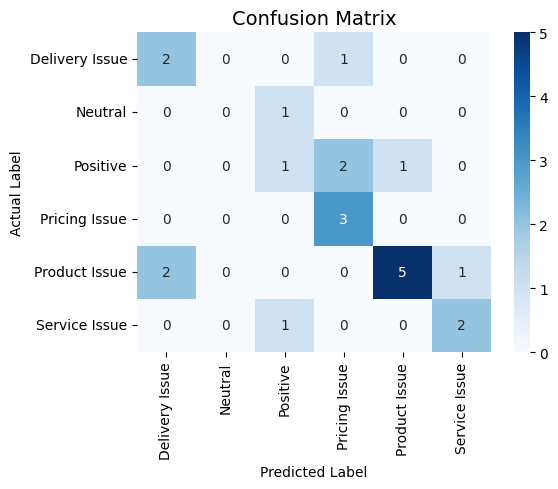

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

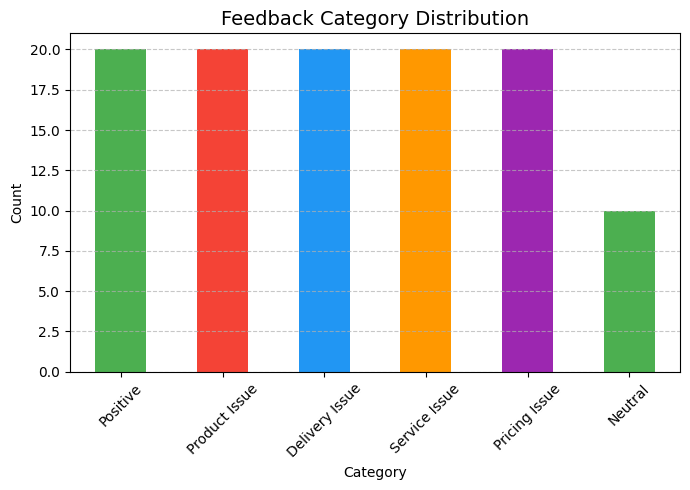

In [30]:
plt.figure(figsize=(7,5))

df['category'].value_counts().plot(
    kind='bar',
    color=['#4CAF50','#F44336','#2196F3','#FF9800','#9C27B0']
)

plt.title("Feedback Category Distribution", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

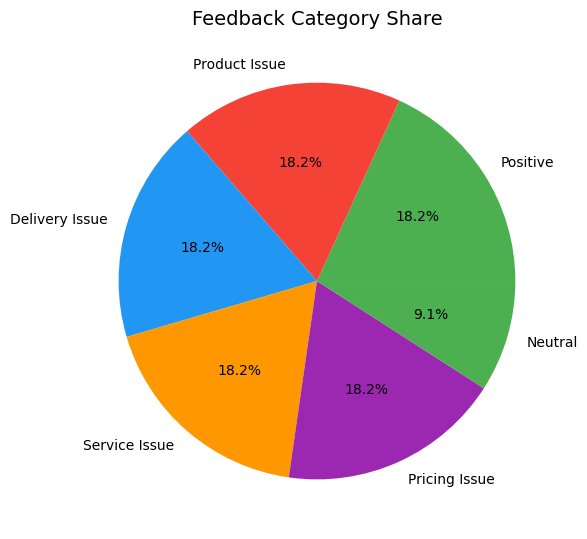

In [31]:
plt.figure(figsize=(6,6))

df['category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#4CAF50','#F44336','#2196F3','#FF9800','#9C27B0']
)

plt.title("Feedback Category Share", fontsize=14)
plt.ylabel("")

plt.tight_layout()
plt.show()

In [32]:
sample_data = pd.DataFrame({
    'Feedback': [
        "delivery was late",
        "great product quality",
        "customer service was rude"
    ]
})

sample_data['Predicted Category'] = sample_data['Feedback'].apply(predict_feedback)

print("Sample Predictions:")
display(sample_data)

Sample Predictions:


,Feedback,Predicted Category
0,delivery was late,Delivery Issue
1,great product quality,Positive
2,customer service was rude,Service Issue


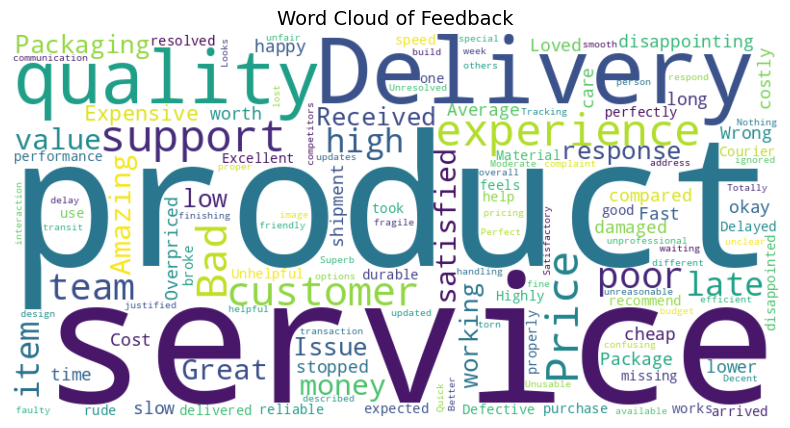

In [33]:
from wordcloud import WordCloud

text = " ".join(df['feedback'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Feedback", fontsize=14)
plt.show()